In [3]:
!pip install pandas numpy matplotlib seaborn

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.4 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.9 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.9 MB 1.3 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.9 MB 1.3 MB/s eta 0:00:07
   ------ --------------------------------- 1.6/9.9 MB 1.3 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.9 MB 1.3 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.9 MB 1.3 MB/s eta 0:00:06
   --------- ------------------------------ 2.4/9.9 MB 1.3 MB/s eta 0:00:06
   ---------- ----------------------------- 2.6/9.9 MB 1.3 MB/s eta 0:00:06
   ----------- ---------------------------- 2.9/9.9 MB 1.3 MB/s eta 0:00:06
   ------------ --------------------------- 3.1/9.9 MB 1.3 MB/s eta 0:00:06
   ------------- ---------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map column titles from our dataset documentation
columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

# 2. Load the space-separated file 
file_name = "4) house Prediction Data Set - 4) house Prediction Data Set.csv"
df = pd.read_csv(file_name, sep=r'\s+', names=columns, header=None)

# 3. Print structural integrity checks
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nMissing Values Count per Column:")
print(df.isna().sum())

Dataset Shape: 506 rows, 14 columns

Missing Values Count per Column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


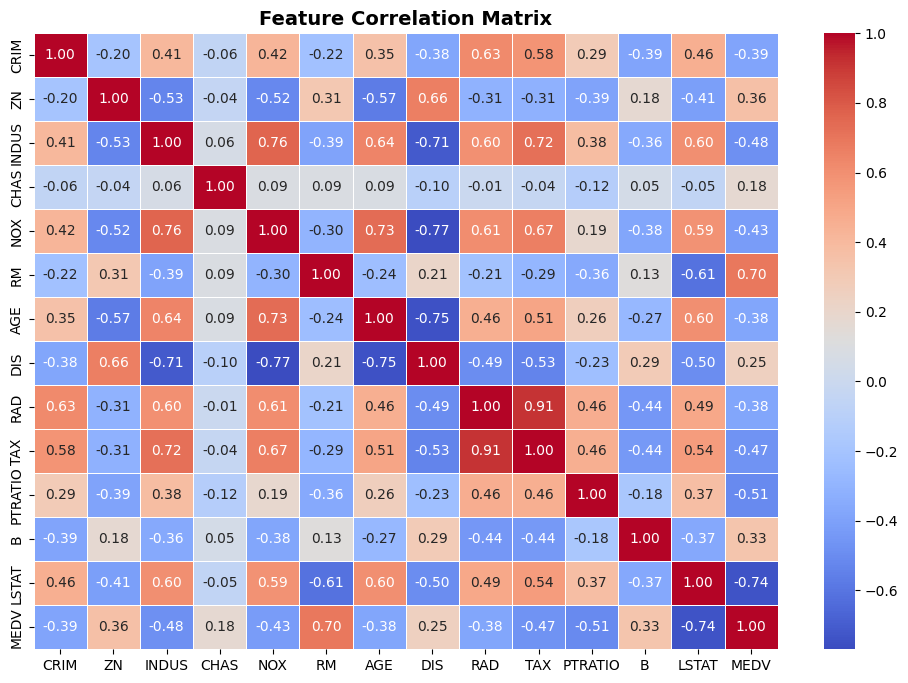

In [5]:
# 1. Compute pairwise correlation coefficients
correlation_matrix = df.corr()

# 2. Render the color-coded matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

In [7]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.3 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/8.3 MB 1.1 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/8.3 MB 1.1 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.3 MB 834.7 kB/s eta 0:00:09
   ----- ---------------------------------- 1.0/8.3 MB 834.7 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.3 MB 786.7 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.3 MB 786.7 kB/s eta 0:00:09
   ------- -------------------------------- 1.6/8.3 MB 778.7 kB/s eta 0:00:09
   -------- ------------------------------- 1.8/8.3 MB 793.7 kB/s eta 0:00:09
   ---------- ----------------------------- 2.1/8.3 MB 807.3 kB/s eta 0:00:08
   ---------- -----


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from sklearn.model_selection import train_test_split

# 1. Isolate the 13 input features (X) and the target price (y)
X = df.drop(columns=['MEDV'])
y = df['MEDV']

# 2. Split the data: 80% for training the model, 20% hidden for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- DATA PARTITIONING COMPLETE ---")
print(f"Training set (80%): {X_train.shape[0]} houses")
print(f"Testing set (20%):  {X_test.shape[0]} houses")

--- DATA PARTITIONING COMPLETE ---
Training set (80%): 404 houses
Testing set (20%):  102 houses


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize the Linear Regression algorithm and train it on the 404 training houses
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Force the model to predict prices for the 102 hidden test houses
lr_preds = lr_model.predict(X_test)

# 3. Calculate performance metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("--- Linear Regression Performance ---")
print(f"Average Prediction Error (RMSE): ${lr_rmse:.2f} thousand")
print(f"Model Variance Explained (R2): {lr_r2*100:.2f}%")

--- Linear Regression Performance ---
Average Prediction Error (RMSE): $4.93 thousand
Model Variance Explained (R2): 66.88%


In [10]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Random Forest algorithm and train it
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict prices on the hidden test houses
rf_preds = rf_model.predict(X_test)

# 3. Calculate performance metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("--- Random Forest Regressor Performance ---")
print(f"Average Prediction Error (RMSE): ${rf_rmse:.2f} thousand")
print(f"Model Variance Explained (R2): {rf_r2*100:.2f}%")

--- Random Forest Regressor Performance ---
Average Prediction Error (RMSE): $2.81 thousand
Model Variance Explained (R2): 89.25%


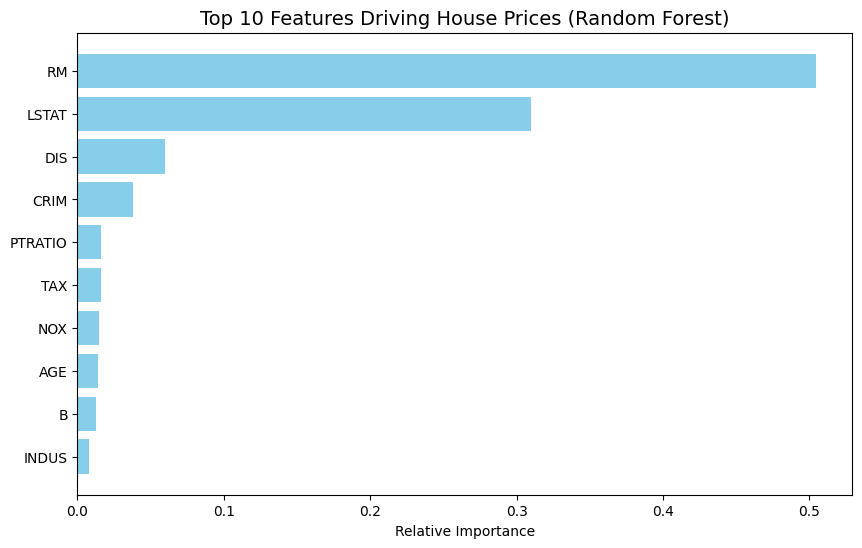

In [11]:
# Extract feature importances from the winning Random Forest model
importances = rf_model.feature_importances_
features = X.columns

# Create a dataframe to sort them neatly
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the results
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10], color='skyblue')
plt.gca().invert_yaxis()  # Put the most important at the top
plt.title('Top 10 Features Driving House Prices (Random Forest)', fontsize=14)
plt.xlabel('Relative Importance')
plt.show()

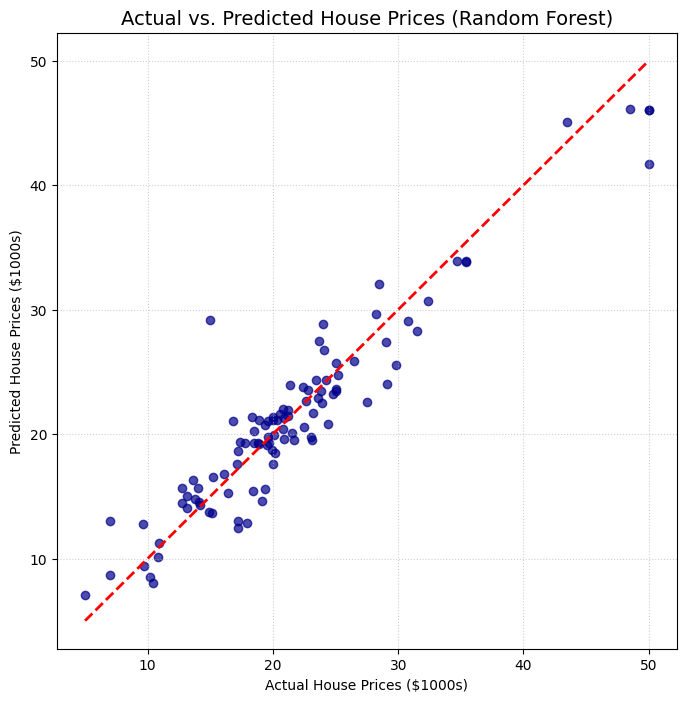

In [12]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, rf_preds, alpha=0.7, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
plt.xlabel('Actual House Prices ($1000s)')
plt.ylabel('Predicted House Prices ($1000s)')
plt.title('Actual vs. Predicted House Prices (Random Forest)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()